In [1]:
!pip install git+https://github.com/huggingface/diffusers
!pip install -U transformers accelerate sentencepiece

  Cloning https://github.com/huggingface/diffusers to /tmp/pip-req-build-qtprbwm4
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/diffusers /tmp/pip-req-build-qtprbwm4
  Resolved https://github.com/huggingface/diffusers to commit d31061b2aca310ea1f18b0b925a63cb6d20f6495
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for diffusers: filename=diffusers-0.38.0.dev0-py3-none-any.whl size=5123301 sha256=e4e0c5178d932cfd9e8a904f171a583d4ded87a1a23e12ce0ea385c7a256db04
  Stored in directory: /tmp/pip-ephem-wheel-cache-kay1t3em/wheels/90/d4/44/a58bc00fb405fefb633b0d9d2307f6e3aec6cc1775d82555d3
Successfully built diffusers
  Attempting uninstall: diffusers
    Found existing installation: diffusers 0.37.1
    Uninstalling diffusers-0.37.1:
      Successfully uninstalled diffusers-0.37.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 93.7 MB/s eta

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
project_path = '/content/drive/MyDrive/CASteer_CV'
os.chdir(project_path)

print("Current Working Directory:", os.getcwd())
print("Files in this directory:", os.listdir())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Working Directory: /content/drive/MyDrive/CASteer_CV
Files in this directory: ['compute_steering_vectors.py', 'generate_casteer.py', 'imagenet_classes.txt', 'construct_prompts.py', 'README.md', '__pycache__', 'controller.py', 'casteer_raw_v1.ipynb', 'cache', 'steering_vectors', 'construct_prompts_mod.py', 'steering_vectors2', 'steering_vectors3', 'steering_vectors4', 'steering_vectors5']


In [2]:
import torch
from diffusers import StableDiffusionPipeline

# Configuration
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "CompVis/stable-diffusion-v1-4"

# Load Pipeline
print("Loading model... this takes about 30-60 seconds...")
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    variant="fp16"
).to(device)

print("Diffusion Model loaded")

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading model... this takes about 30-60 seconds...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--CompVis--stable-diffusion-v1-4/snapshots/133a221b8aa7292a167afc5127cb63fb5005638b/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Diffusion Model loaded


In [3]:
# ── Cell: Qwen Subclass Generation & Setup ──────────────────────────────────
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch, re, os

# 1. Load the Qwen Model
MODEL_ID  = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
model     = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)
print("Language Model loaded")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Language Model loaded


In [4]:
# 2. Subclass Generator Function
def generate_subclasses(concept, n=10, max_new_tokens=200):
    """
    Generate visually distinct subclasses for the given concept.
    Filters out any outputs suffixed with '(Repeated)'.
    """
    # prompt = (
    #     f"List exactly {n} common, visually distinct subclasses of '{concept}'. "
    #     "Each subclass must be a single everyday word or short phrase "
    #     "that is suitable for image generation, covers the full range "
    #     "of the concept, and is clearly different from the others. "
    #     "Reply ONLY with a numbered list. No explanations. "
    #     "If you cannot think of enough unique items, append '(Repeated)' to the duplicate words."
    # )

    prompt = (
        f"List exactly {n} common, unique subclasses related to '{concept}'. "
        "Each subclass must be a single everyday word. "
        "These vectors will be used to make machine unlearning of the concept more robust. "
        f"So the {n} subclasses should be such that they cover the full range of the concept. "
        "Do not give abbreviated words. "
        "Do not give scientific terms either, give commonly used words only."
        "Reply ONLY with a NUMBERED list. No explanations. "
    )



    messages = [
        {"role": "system", "content": "You are a helpful assistant that outputs concise, structured lists."},
        {"role": "user", "content": prompt}
    ]

    text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer([text], return_tensors="pt").to(model.device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,          # greedy — more predictable output
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    # Strip the input tokens to get only the generated part
    generated = output_ids[0][inputs.input_ids.shape[-1]:]
    raw = tokenizer.decode(generated, skip_special_tokens=True)

    print(raw)

    # Parse numbered list → clean Python list
    items = re.findall(r'^\s*\d+[.)\]]\s*(.+)', raw, re.MULTILINE)

    clean_items = []
    for x in items:
        x = x.strip()
        # Filter out anything flagged as repeated or exact duplicates
        if "(repeated)" not in x and x.lower() not in [item.lower() for item in clean_items]:
            clean_items.append(x.lower())

    return clean_items[:n]


# 3. Run Pipeline and Set Concepts
PARENT_CONCEPT = "vehicle"  # <--- Specify your parent concept here
# PARENT_CONCEPT = "furniture"
# PARENT_CONCEPT = "hand tool"
N = 10

subclasses = generate_subclasses(PARENT_CONCEPT, n=N)

# Recreate the concepts_to_unlearn list
concepts_to_unlearn = [PARENT_CONCEPT] + subclasses

print(f"\nGenerated Subclasses for '{PARENT_CONCEPT}':")
for i, s in enumerate(subclasses, 1):
    print(f"  {i}. {s}")

print(f"\nFinal concepts_to_unlearn list: {concepts_to_unlearn}\n")

# 4. Directory Setup (from original pipeline)
SAVE_DIR = f'/content/drive/MyDrive/CASteer_CV/steering_vectors6/{PARENT_CONCEPT}_vecs'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Steering vectors will be saved to: {SAVE_DIR}")

The following generation flags are not valid and may be ignored: ['top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


1. Car
2. Motorcycle
3. Bus
4. Truck
5. Bicycle
6. Van
7. Scooter
8. Airplane
9. Boat
10. Train

Generated Subclasses for 'vehicle':
  1. car
  2. motorcycle
  3. bus
  4. truck
  5. bicycle
  6. van
  7. scooter
  8. airplane
  9. boat
  10. train

Final concepts_to_unlearn list: ['vehicle', 'car', 'motorcycle', 'bus', 'truck', 'bicycle', 'van', 'scooter', 'airplane', 'boat', 'train']

Steering vectors will be saved to: /content/drive/MyDrive/CASteer_CV/steering_vectors6/vehicle_vecs


In [6]:
# # @title
# import numpy as np
# import pickle
# from collections import defaultdict
# from tqdm.auto import tqdm
# from construct_prompts_mod import get_prompts_concrete
# from controller import VectorStore, register_vector_control


# NUM_DENOISING_STEPS = 50
# NUM_PROMPT_PAIRS    = 20


# def run_model(pipe, prompt, num_denoising_steps, device):
#     image = pipe(
#         prompt=prompt,
#         num_inference_steps=num_denoising_steps,
#         generator=torch.Generator(device=device)
#     ).images[0]
#     return image


# def compute_steering_vector_for_concept(pipe, concept_pos, num_prompt_pairs,
#                                         num_denoising_steps, device):
#     prompts_pos, prompts_neg = get_prompts_concrete(
#         num=num_prompt_pairs,
#         concept_pos=concept_pos,
#         concept_neg=None
#     )

#     pos_vectors = []
#     neg_vectors = []

#     # ── prompt-pair loop ──────────────────────────────────────────────────────
#     pair_bar = tqdm(
#         enumerate(zip(prompts_pos, prompts_neg)),
#         total=len(prompts_pos),
#         desc=f"  [{concept_pos}] Prompt pairs",
#         unit="pair",
#         leave=True,
#     )
#     for i, (prompt_pos, prompt_neg) in pair_bar:
#         pair_bar.set_postfix_str(f"+ {prompt_pos[:40]}…")

#         # positive pass
#         controller = VectorStore()
#         controller.steer = False
#         register_vector_control(pipe.unet, controller)
#         run_model(pipe, prompt_pos, num_denoising_steps, device)
#         pos_vectors.append(controller.vector_store)

#         # negative pass
#         controller = VectorStore()
#         controller.steer = False
#         register_vector_control(pipe.unet, controller)
#         run_model(pipe, prompt_neg, num_denoising_steps, device)
#         neg_vectors.append(controller.vector_store)

#     # ── steering vector computation ───────────────────────────────────────────
#     steering_vectors = {}
#     step_bar = tqdm(
#         range(num_denoising_steps),
#         desc=f"  [{concept_pos}] Computing vectors",
#         unit="step",
#         leave=True,
#     )
#     for denoising_step in step_bar:
#         steering_vectors[denoising_step] = defaultdict(list)

#         for key in ['up', 'down', 'mid']:
#             num_layers = len(pos_vectors[0][denoising_step][key])
#             for layer_num in range(num_layers):

#                 pos_layer = [pos_vectors[i][denoising_step][key][layer_num]
#                              for i in range(len(pos_vectors))]
#                 pos_avg = np.mean(pos_layer, axis=0)

#                 neg_layer = [neg_vectors[i][denoising_step][key][layer_num]
#                              for i in range(len(neg_vectors))]
#                 neg_avg = np.mean(neg_layer, axis=0)

#                 sv = pos_avg - neg_avg
#                 sv = sv / np.linalg.norm(sv)

#                 steering_vectors[denoising_step][key].append(sv)

#         step_bar.set_postfix(keys_done=3)

#     return steering_vectors


# # ── outer concept loop ────────────────────────────────────────────────────────
# concept_bar = tqdm(
#     concepts_to_unlearn,
#     desc="Concepts",
#     unit="concept",
#     leave=True,
#     position=0,
# )
# for concept in concept_bar:
#     concept_bar.set_description(f"Concepts  (current: {concept})")

#     sv = compute_steering_vector_for_concept(
#         pipe=pipe,
#         concept_pos=concept,
#         num_prompt_pairs=NUM_PROMPT_PAIRS,
#         num_denoising_steps=NUM_DENOISING_STEPS,
#         device=device,
#     )

#     safe_name = concept.replace(" ", "_")
#     save_path = os.path.join(SAVE_DIR, f"sd14_{safe_name}.pickle")
#     with open(save_path, 'wb') as f:
#         pickle.dump(sv, f)

#     tqdm.write(f"Saved steering vector for '{concept}' → {save_path}")

# tqdm.write("\nAll steering vectors computed and saved")

# import time
# time.sleep(10)

# from google.colab import runtime
# runtime.unassign()

# @title
import numpy as np
import pickle
import os
import torch
from collections import defaultdict
from tqdm.auto import tqdm
from construct_prompts_mod import get_prompts_concrete
from controller import VectorStore, register_vector_control


NUM_DENOISING_STEPS = 50

def run_model(pipe, prompt, num_denoising_steps, device):
    image = pipe(
        prompt=prompt,
        num_inference_steps=num_denoising_steps,
        generator=torch.Generator(device=device)
    ).images[0]
    return image


def compute_steering_vector_for_concept(pipe, concept_pos, num_prompt_pairs,
                                        num_denoising_steps, device):
    prompts_pos, prompts_neg = get_prompts_concrete(
        num=num_prompt_pairs,
        concept_pos=concept_pos,
        concept_neg=None
    )

    pos_vectors = []
    neg_vectors = []

    # ── prompt-pair loop ──────────────────────────────────────────────────────
    pair_bar = tqdm(
        enumerate(zip(prompts_pos, prompts_neg)),
        total=len(prompts_pos),
        desc=f"  [{concept_pos}] Prompt pairs",
        unit="pair",
        leave=True,
    )
    for i, (prompt_pos, prompt_neg) in pair_bar:
        pair_bar.set_postfix_str(f"+ {prompt_pos[:40]}…")

        # positive pass
        controller = VectorStore()
        controller.steer = False
        register_vector_control(pipe.unet, controller)
        run_model(pipe, prompt_pos, num_denoising_steps, device)
        pos_vectors.append(controller.vector_store)

        # negative pass
        controller = VectorStore()
        controller.steer = False
        register_vector_control(pipe.unet, controller)
        run_model(pipe, prompt_neg, num_denoising_steps, device)
        neg_vectors.append(controller.vector_store)

    # ── steering vector computation ───────────────────────────────────────────
    steering_vectors = {}
    step_bar = tqdm(
        range(num_denoising_steps),
        desc=f"  [{concept_pos}] Computing vectors",
        unit="step",
        leave=True,
    )
    for denoising_step in step_bar:
        steering_vectors[denoising_step] = defaultdict(list)

        for key in ['up', 'down', 'mid']:
            num_layers = len(pos_vectors[0][denoising_step][key])
            for layer_num in range(num_layers):

                pos_layer = [pos_vectors[i][denoising_step][key][layer_num]
                             for i in range(len(pos_vectors))]
                pos_avg = np.mean(pos_layer, axis=0)

                neg_layer = [neg_vectors[i][denoising_step][key][layer_num]
                             for i in range(len(neg_vectors))]
                neg_avg = np.mean(neg_layer, axis=0)

                sv = pos_avg - neg_avg
                sv = sv / np.linalg.norm(sv)

                steering_vectors[denoising_step][key].append(sv)

        step_bar.set_postfix(keys_done=3)

    return steering_vectors


# ── outer concept loop ────────────────────────────────────────────────────────
concept_bar = tqdm(
    enumerate(concepts_to_unlearn), # Added enumerate here to track the index
    total=len(concepts_to_unlearn), # Explicitly specify total since enumerate obscures the length
    desc="Concepts",
    unit="concept",
    leave=True,
    position=0,
)

for i, concept in concept_bar:
    concept_bar.set_description(f"Concepts  (current: {concept})")

    # Set 50 pairs for the first concept (index 0), 20 for the rest
    current_num_pairs = 50 if i == 0 else 20

    sv = compute_steering_vector_for_concept(
        pipe=pipe,
        concept_pos=concept,
        num_prompt_pairs=current_num_pairs, # Pass dynamic value here
        num_denoising_steps=NUM_DENOISING_STEPS,
        device=device,
    )

    safe_name = concept.replace(" ", "_")
    save_path = os.path.join(SAVE_DIR, f"sd14_{safe_name}.pickle")
    with open(save_path, 'wb') as f:
        pickle.dump(sv, f)

    tqdm.write(f"Saved steering vector for '{concept}' ({current_num_pairs} pairs) → {save_path}")

tqdm.write("\nAll steering vectors computed and saved")

import time
time.sleep(5)

from google.colab import runtime
runtime.unassign()

Concepts:   0%|          | 0/11 [00:00<?, ?concept/s]

  [vehicle] Prompt pairs:   0%|          | 0/50 [00:00<?, ?pair/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  [train] Computing vectors:   0%|          | 0/50 [00:00<?, ?step/s]

Saved steering vector for 'train' (20 pairs) → /content/drive/MyDrive/CASteer_CV/steering_vectors6/vehicle_vecs/sd14_train.pickle

All steering vectors computed and saved


In [ ]:
# @title
import pickle
import numpy as np
import torch
from collections import defaultdict
from tqdm.auto import tqdm
from controller import VectorStore, register_vector_control
from diffusers import StableDiffusionPipeline

LOAD_DIR = '/content/drive/MyDrive/CASteer_CV/steering_vectors5'
concepts_to_unlearn = ['vehicle', 'car', 'motorcycle', 'scooter', 'bicyclist', 'electric vehicle (ev)', 'hybrid vehicle', 'van', 'bus', 'truck']

class MultiConceptVectorStore(VectorStore):
    """
    Subtracts multiple steering vectors independently during generation.
    For each concept vector sv_i:
        ca_out -= clip(beta * <sv_i, ca_out>, 0) * sv_i
    """

    def __init__(self, all_steering_vectors, beta=2, device='cuda'):
        super().__init__(
            steering_vectors=all_steering_vectors[0],
            steer=True,
            device=device
        )
        self.all_steering_vectors = all_steering_vectors
        self.beta  = beta
        self.steer = True

    def forward(self, vector, place_in_unet: str):
        if self.steer and place_in_unet in ['up', 'mid', 'down']:

            layer_idx = len(self.step_store[place_in_unet])

            for sv_dict in self.all_steering_vectors:
                num_steer = 0 if len(sv_dict) == 1 else self.cur_step

                if num_steer not in sv_dict:
                    continue
                if layer_idx >= len(sv_dict[num_steer][place_in_unet]):
                    continue

                sv   = sv_dict[num_steer][place_in_unet][layer_idx]
                sv_t = torch.tensor(sv, dtype=vector.dtype, device=self.device).view(1, 1, -1)

                sim = torch.tensordot(
                    vector, sv_t, dims=([2], [2])
                ).view(vector.size(0), vector.size(1), 1)

                sim    = torch.clamp(sim, min=0.0)
                vector = vector - (self.beta * sim) * sv_t.expand(1, vector.size(1), -1)

        self.step_store[place_in_unet].append(
            vector.data.cpu().numpy()[len(vector) // 2:].mean(axis=0).mean(axis=0)
        )
        return vector


# ── load all saved steering vectors ──────────────────────────────────────────
def load_all_steering_vectors(concepts, load_dir):
    loaded = []
    load_bar = tqdm(concepts, desc="Loading steering vectors", unit="concept")
    for concept in load_bar:
        load_bar.set_postfix_str(concept)
        safe_name = concept.replace(" ", "_")
        path = os.path.join(load_dir, f"sd14_{safe_name}.pickle")
        with open(path, 'rb') as f:
            sv = pickle.load(f)
        loaded.append(sv)
        tqdm.write(f"Loaded '{concept}' from {path}")
    return loaded


print("Loading all steering vectors...")
all_sv = load_all_steering_vectors(concepts_to_unlearn, LOAD_DIR)
print("Done.\n")


# ── generation helpers ────────────────────────────────────────────────────────
def generate_multi_concept_erased(pipe, prompt, num_denoising_steps,
                                   all_steering_vectors, beta=2, device='cuda'):
    controller = MultiConceptVectorStore(
        all_steering_vectors=all_steering_vectors,
        beta=beta,
        device=device
    )
    register_vector_control(pipe.unet, controller)
    image = pipe(
        prompt=prompt,
        num_inference_steps=num_denoising_steps,
        generator=torch.Generator(device=device)
    ).images[0]
    return image


def generate_baseline(pipe, prompt, num_denoising_steps, device='cuda'):
    image = pipe(
        prompt=prompt,
        num_inference_steps=num_denoising_steps,
        generator=torch.Generator(device=device)
    ).images[0]
    return image


Loading all steering vectors...


Loading steering vectors:   0%|          | 0/10 [00:00<?, ?concept/s]

Loaded 'vehicle' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_vehicle.pickle
Loaded 'car' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_car.pickle
Loaded 'motorcycle' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_motorcycle.pickle
Loaded 'scooter' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_scooter.pickle
Loaded 'bicyclist' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_bicyclist.pickle
Loaded 'electric vehicle (ev)' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_electric_vehicle_(ev).pickle
Loaded 'hybrid vehicle' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_hybrid_vehicle.pickle
Loaded 'van' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_van.pickle
Loaded 'bus' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_bus.pickle
Loaded 'truck' from /content/drive/MyDrive/CASteer_CV/steering_vectors5/sd14_truck.pickle
Done.



Generating images:   0%|          | 0/1 [00:00<?, ?prompt/s]

  Steered   → "helicopters in the sky"


  0%|          | 0/50 [00:00<?, ?it/s]

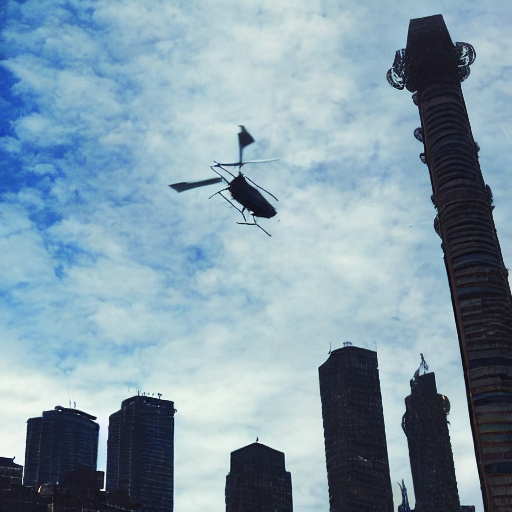


All done!


In [ ]:
from PIL import Image

BETA       = 2
NUM_STEPS  = 50
# OUTPUT_DIR = '/content/drive/MyDrive/CASteer_CV/outputs_multi_concept'
# os.makedirs(OUTPUT_DIR, exist_ok=True)

test_prompts = [
    # "sports car parked under neon lights",
    # "a futuristic spaceship"
    # "a car near a tree"
    # "helicopters in the sky"
]

prompt_bar = tqdm(test_prompts, desc="Generating images", unit="prompt", position=0)
for prompt in prompt_bar:
    safe_prompt = prompt[:60].replace(" ", "_").replace("/", "-")
    prompt_bar.set_postfix_str(f'"{prompt[:35]}…"')

    # # baseline
    # tqdm.write(f'\n  Baseline  → "{prompt}"')
    # img_base = generate_baseline(pipe, prompt, NUM_STEPS, device)
    # img_base.save(os.path.join(OUTPUT_DIR, f"baseline_{safe_prompt}.png"))

    # steered
    tqdm.write(f'  Steered   → "{prompt}"')
    img_steered = generate_multi_concept_erased(
        pipe, prompt, NUM_STEPS,
        all_sv, beta=BETA, device=device
    )
    display(img_steered)
    # img_steered.save(os.path.join(OUTPUT_DIR, f"steered_{safe_prompt}.png"))

    # # side-by-side
    # comparison = Image.new('RGB', (img_base.width * 2 + 10, img_base.height), (200, 200, 200))
    # comparison.paste(img_base,    (0, 0))
    # comparison.paste(img_steered, (img_base.width + 10, 0))
    # comparison.save(os.path.join(OUTPUT_DIR, f"compare_{safe_prompt}.png"))

    # tqdm.write(f'Saved to {OUTPUT_DIR}')

tqdm.write("\nAll done!")